In [15]:
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [12]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

# Hierachical Clustering


- **Why not K-Means**
  - heavily dependent with distances between points
  - Can't deal with outliers

    
- **How to solve K-Means Problems**
  - Hierachical Clustring
  - Density Based Clustring (DBSCAN)

    
- **Types of Hierarchical Clustering**
  1) Agglomerative Clustering (Most Use)
  2) Divisive Clustering


1) **Agglomerative Clustering**
   - **Step 1** Every point is a cluster
   - **Step 2** Closest points/clusters become one cluster
   - **Step 3** Repeat Step 2 till there is only one cluster (no. of cluster needed)
![image](https://miro.medium.com/v2/resize:fit:1352/1*_ygmiFhggEVolNI-iF9yVA.gif)

**Note All recodes of murging need to be stored at some place**

2) **Divisive Clustering**
   - **Step 1** Asumes there is only *ONE* Cluster
   - **Step 2** Break down to smaller clusters till there are equal number of cluster as number of poits (no. of cluster needed)

**Note work compleatly oppositly to Agglomerative Clustering**

## Algorithm
1. Initialize the proximity matrix
2. Make each point a cluster
3. Inside a loop
   - Merge the 2 closest clusters
   - Update the Proximity Matrix
4. Loop until only oe cluster is left (no. of cluster needed)

### Proximity Matrix
![image](https://quantdare.com/wp-content/uploads/2022/05/imagen-0-1.png)

**Where Cell pp, pq, pr, ps ....... represents the distance between points**

## How to calculate the distance after forming cluster

    In Sk-Learn there are types of Agglomerative Clustering to handel this
    Types:
        1) Min (Single-Link)
        2) Max (Complete-Link)
        3) Average
        4) Ward

![image](https://www.researchgate.net/publication/333845151/figure/fig5/AS:771108269723649@1560857946451/schematic-representation-of-the-linkage-methods-single-link-complete-link-and.ppm)

## How to find the ideal number of clusters

    Using dendrogram
        Need longes vertical line

    Note Vertical line (Y-exis) represent the distance between clusters

## Benefits
1. Widely applicable
2. Dendrogra

       We have all the info related to nearist nabours

## Limitation
1. Can't work with biger data

       Because of Proximity Matrix

# Laod Dataset

In [4]:
X, y = load_iris(return_X_y=True)

# Min (Single-Link)

    Finds all the distance and take the minimum distance

    Can't handle outliers

In [22]:
Aggclu = AgglomerativeClustering(n_clusters=3,linkage='single',compute_full_tree=False)
pred = Aggclu.fit_predict(X,y)

In [23]:
pca = PCA(n_components=2)
X_tran = pca.fit_transform(X)

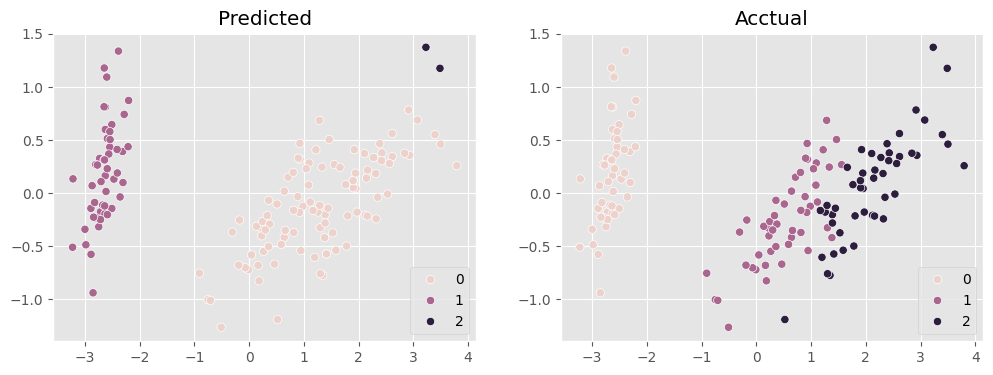

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=pred)
plt.title('Predicted')
plt.subplot(122)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=y)
plt.title('Acctual')
plt.show()

# Max (Complete-Link)

    Finds all the distance and take the minimum distance

    Can handle outliers
    If in our dataset 'One cluster is too bigger/small" then the bigger cluster will break

In [25]:
Aggclu = AgglomerativeClustering(n_clusters=3,linkage='complete',compute_full_tree=False)
pred = Aggclu.fit_predict(X,y)

In [26]:
pca = PCA(n_components=2)
X_tran = pca.fit_transform(X)

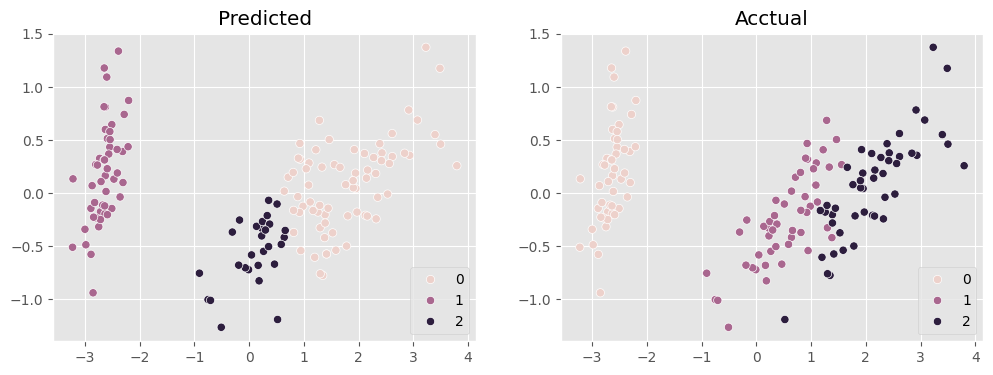

In [27]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=pred)
plt.title('Predicted')
plt.subplot(122)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=y)
plt.title('Acctual')
plt.show()

# Average

    Taking mean of all the distance calculated

In [28]:
Aggclu = AgglomerativeClustering(n_clusters=3,linkage='average',compute_full_tree=False)
pred = Aggclu.fit_predict(X,y)

In [29]:
pca = PCA(n_components=2)
X_tran = pca.fit_transform(X)

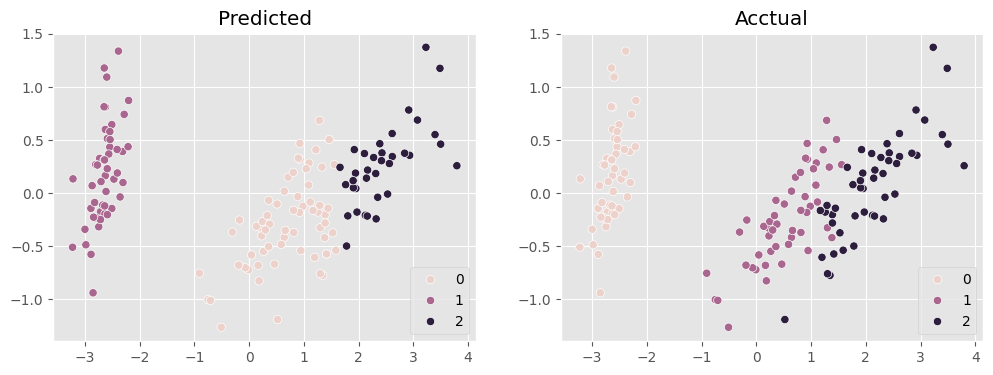

In [30]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=pred)
plt.title('Predicted')
plt.subplot(122)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=y)
plt.title('Acctual')
plt.show()

# Ward

    1) Find the centroid of the two cluster and the distance between centroid and each points (C1, C2, C3 ....... Cn)

    2) Find mean of each cluster and distance within cluster between mead and points {A1, A2, A3 .... An} & {B1, B2, B3 .... Bn}

    3) distace = ( (C1)^2 + (C2)^2 + (C3)^2 .... (Cn)^2 ) + ( (A1)^2, (A2)^2, (A3)^2 .... (An)^2 ) + ( (B1)^2, (B2)^2, (B3)^2 .... (Bn)^2 )

    It minimize the varience

In [18]:
Aggclu = AgglomerativeClustering(n_clusters=3,linkage='ward',compute_full_tree=False)
pred = Aggclu.fit_predict(X,y)

In [19]:
pca = PCA(n_components=2)
X_tran = pca.fit_transform(X)

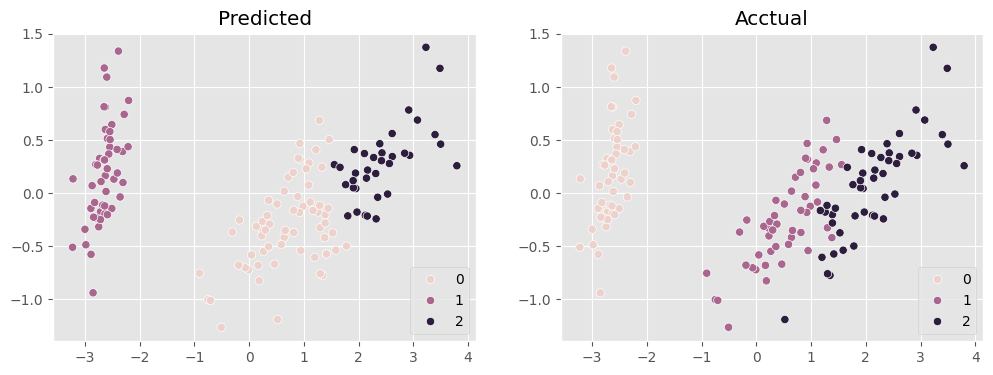

In [21]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=pred)
plt.title('Predicted')
plt.subplot(122)
sns.scatterplot(x=X_tran[:,0],y=X_tran[:,1],hue=y)
plt.title('Acctual')
plt.show()

# Dendogram

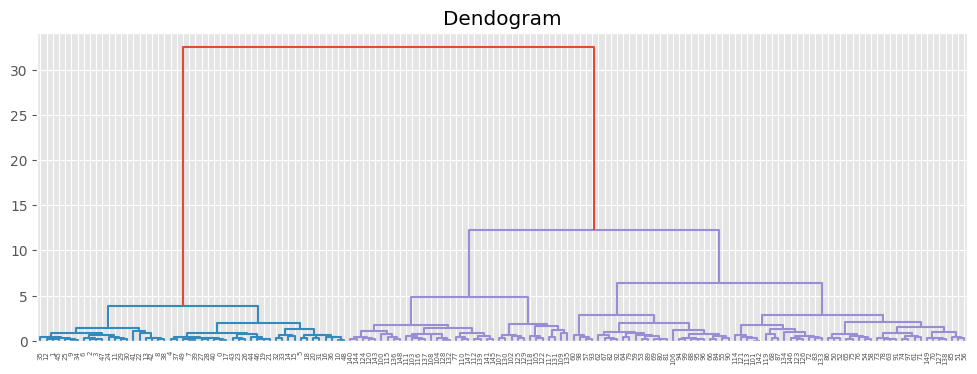

In [39]:
plt.figure(figsize=(12,4))
temp = shc.linkage(X, 'ward')
dn = shc.dendrogram(temp)
plt.title("Dendogram")
plt.show()